# Neural Operator Tutorial: Learning Maps Between Function Spaces

This notebook studies the neural-operator viewpoint introduced by Kovachki et al., *Neural Operator: Learning Maps Between Function Spaces* (JMLR 2023). The goal is not just to run a model, but to connect:

- the **operator-learning problem** $G^\dagger : \mathcal{A} \to \mathcal{U}$
- the **discretization-invariant neural operator architecture**
- the **Fourier neural operator (FNO)** specialization
- an **exactly solvable PDE family** that lets us verify the data-generating operator
- **resolution transfer** from a coarse training grid to a finer evaluation grid

The notebook is divided into two parts:

| Part | Problem | Dimension | Data source |
|------|---------|-----------|-------------|
| **I** | Variable-coefficient diffusion | 1-D | Exact integral formula |
| **II** | Darcy flow with GRF coefficients | 2-D | Finite-difference solver |

Primary references:

- Kovachki et al. (2023), *Neural Operator: Learning Maps Between Function Spaces*, JMLR 24:1-97
- Li et al. (2021), *Fourier Neural Operator for Parametric Partial Differential Equations*, ICLR 2021


## 1 — Theory: What Is a Neural Operator?

The paper formulates operator learning as the task of approximating a nonlinear map

$$
G^\dagger : \mathcal{A} \to \mathcal{U},
$$

where both the input and the output live in infinite-dimensional function spaces. Instead of learning a mapping between fixed-size vectors, we learn a map between **functions**.

The paper emphasizes three core ideas:

1. **Discretization invariance**: the same learned parameters should work across different discretizations.
2. **Neural operator layers**: each layer is itself an operator, not just a matrix acting on a fixed-size vector.
3. **Universal approximation of continuous operators**: the neural-operator family can approximate continuous nonlinear operators on compact sets.

At a high level, the architecture is:

$$
v_0(x) = P(a(x)), \qquad
v_{t+1}(x) = \sigma\left(W_t v_t(x) + \int \kappa_t(x, y) v_t(y)\, d\nu(y) + b_t(x)\right), \qquad
u(x) = Q(v_T(x)).
$$

Here:

- $P$ is a pointwise **lifting** map into a higher-dimensional channel space
- each hidden layer mixes a **local linear path** and a **nonlocal integral operator**
- $Q$ is a pointwise **projection** back to the target function space

In the paper's terminology, this operator-level construction is what allows the model to remain meaningful as the grid changes.


## 2 — Theory: Why Fourier Neural Operators Matter

The Fourier neural operator (FNO) is a practical neural-operator instantiation in which the nonlocal integral operator is parameterized in Fourier space:

1. transform the hidden state into Fourier coefficients via FFT
2. apply a learnable linear map to the **low-frequency modes**
3. invert the transform back to physical space via IFFT
4. add a local linear path (a $1 \times 1$ convolution) and a nonlinearity

This matters for two reasons:

- it reduces operator application cost to roughly **$O(n \log n)$** per layer
- the same learned low-mode parameters can be reused at multiple resolutions, enabling **zero-shot super-resolution**

**Extending to 2-D.**  In the 2-D case, we replace 1-D FFTs with 2-D FFTs and parameterize a weight tensor over the first $(k_x, k_y)$ modes.  The local path becomes a $1 \times 1$ 2-D convolution.  The cost per layer is $O(N \log N)$ where $N = N_x \cdot N_y$.  Crucially, because the spectral weights do not depend on the grid size, the same trained model can be applied at higher resolutions.


---

# Part I — 1-D Variable-Coefficient Diffusion

## 3 — PDE Family

We study the 1-D variable-coefficient diffusion problem

$$
-\big(a(x) u'(x)\big)' = f(x), \qquad x \in (0,1), \qquad u(0)=u(1)=0,
$$

where both:

- the diffusivity $a(x)$ is a random positive function
- the forcing $f(x)$ is a random smooth function

This gives us a true operator $(a, f) \mapsto u$.

The reason this family is excellent for a tutorial is that the solution operator is **nonlocal** but still admits an exact 1-D formula:

$$
C =
\frac{\int_0^1 F(s) / a(s)\, ds}{\int_0^1 1 / a(s)\, ds},
\qquad
u(x) = \int_0^x \frac{C - F(s)}{a(s)}\, ds,
\qquad F(x) = \int_0^x f(s)\, ds.
$$

So the training data is produced by a **verified exact operator formula**, not an approximate solver.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from physics_informed_neural_network.neural_operator.data import (
    build_dataset_splits,
    compute_discrete_diffusion_residual,
)
from physics_informed_neural_network.neural_operator.model import FourierNeuralOperator1d
from physics_informed_neural_network.neural_operator.pipeline import run_neural_operator_experiment
from physics_informed_neural_network.neural_operator.plotting import (
    apply_plot_style,
    plot_dataset_examples,
    plot_frequency_spectrum,
    plot_prediction_comparison,
    plot_resolution_metrics,
    plot_training_history,
)
from physics_informed_neural_network.neural_operator.presets import (
    build_smoke_test_config,
    build_tutorial_config,
    build_darcy_tutorial_config,
    build_darcy_smoke_test_config,
)

# 2-D imports
from physics_informed_neural_network.neural_operator.data_2d import build_darcy_splits
from physics_informed_neural_network.neural_operator.model_2d import FourierNeuralOperator2d
from physics_informed_neural_network.neural_operator.pipeline_2d import run_darcy_experiment
from physics_informed_neural_network.neural_operator.plotting_2d import (
    plot_darcy_dataset_examples,
    plot_darcy_prediction_comparison,
    plot_darcy_error_distribution,
    plot_darcy_resolution_metrics,
    plot_darcy_cross_sections,
)

apply_plot_style()
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 4 — Pydantic Configuration

The tutorial code is structured like library code, not notebook-only code:

- Pydantic config models define the problem, dataset, model, and optimizer
- reusable functions generate exact data at arbitrary resolution
- the FNO model supports variable grid lengths
- the trainer owns normalization, optimization, evaluation, and prediction

Use the tutorial preset for a meaningful run, or swap to `build_smoke_test_config()` for a fast sanity check.


In [2]:
config = build_tutorial_config(output_dir=PROJECT_ROOT / "artifacts" / "notebook_neural_operator")
display(config.model_dump())

{'problem': {'domain_min': 0.0,
  'domain_max': 1.0,
  'diffusion_modes': 8,
  'forcing_modes': 8,
  'diffusion_bias': -0.25,
  'diffusion_amplitude': 0.45,
  'forcing_amplitude': 1.0,
  'spectral_decay': 2.0,
  'minimum_diffusion': 0.15},
 'data': {'train_samples': 256,
  'validation_samples': 64,
  'test_samples': 64,
  'train_resolution': 64,
  'evaluation_resolution': 128,
  'seed': 17},
 'model': {'input_channels': 3,
  'width': 48,
  'modes': 16,
  'layers': 4,
  'padding': 8,
  'activation': 'gelu'},
 'optimization': {'seed': 42,
  'device': 'cpu',
  'batch_size': 32,
  'epochs': 80,
  'learning_rate': 0.003,
  'weight_decay': 1e-05,
  'scheduler_step': 25,
  'scheduler_gamma': 0.7,
  'grad_clip': 1.0,
  'log_every': 10},
 'artifacts': {'output_dir': PosixPath('/Users/rezami/PycharmProjects/physical-informed-neural-network/artifacts/notebook_neural_operator'),
  'save_artifacts': False}}

In [3]:
splits = build_dataset_splits(config)
dataset_frame = pd.DataFrame(
    [
        {"split": "train", "samples": splits.train.n_samples, "resolution": splits.train.resolution},
        {"split": "validation", "samples": splits.validation.n_samples, "resolution": splits.validation.resolution},
        {"split": "test", "samples": splits.test.n_samples, "resolution": splits.test.resolution},
        {"split": "refined_test", "samples": splits.refined_test.n_samples, "resolution": splits.refined_test.resolution},
    ]
)
display(dataset_frame)

,split,samples,resolution
0,train,256,64
1,validation,64,64
2,test,64,64
3,refined_test,64,128


In [4]:
sample = splits.train.sample(0)
exact_residual = compute_discrete_diffusion_residual(
    sample.grid, sample.diffusion, sample.solution, sample.forcing,
)
verification_frame = pd.DataFrame([{
    "u(0)": sample.solution[0],
    "u(1)": sample.solution[-1],
    "mean |residual|": np.mean(np.abs(exact_residual)),
    "max |residual|": np.max(np.abs(exact_residual)),
}])
display(verification_frame)

,u(0),u(1),mean |residual|,max |residual|
0,0.000000,0.000000,0.007873,0.026677


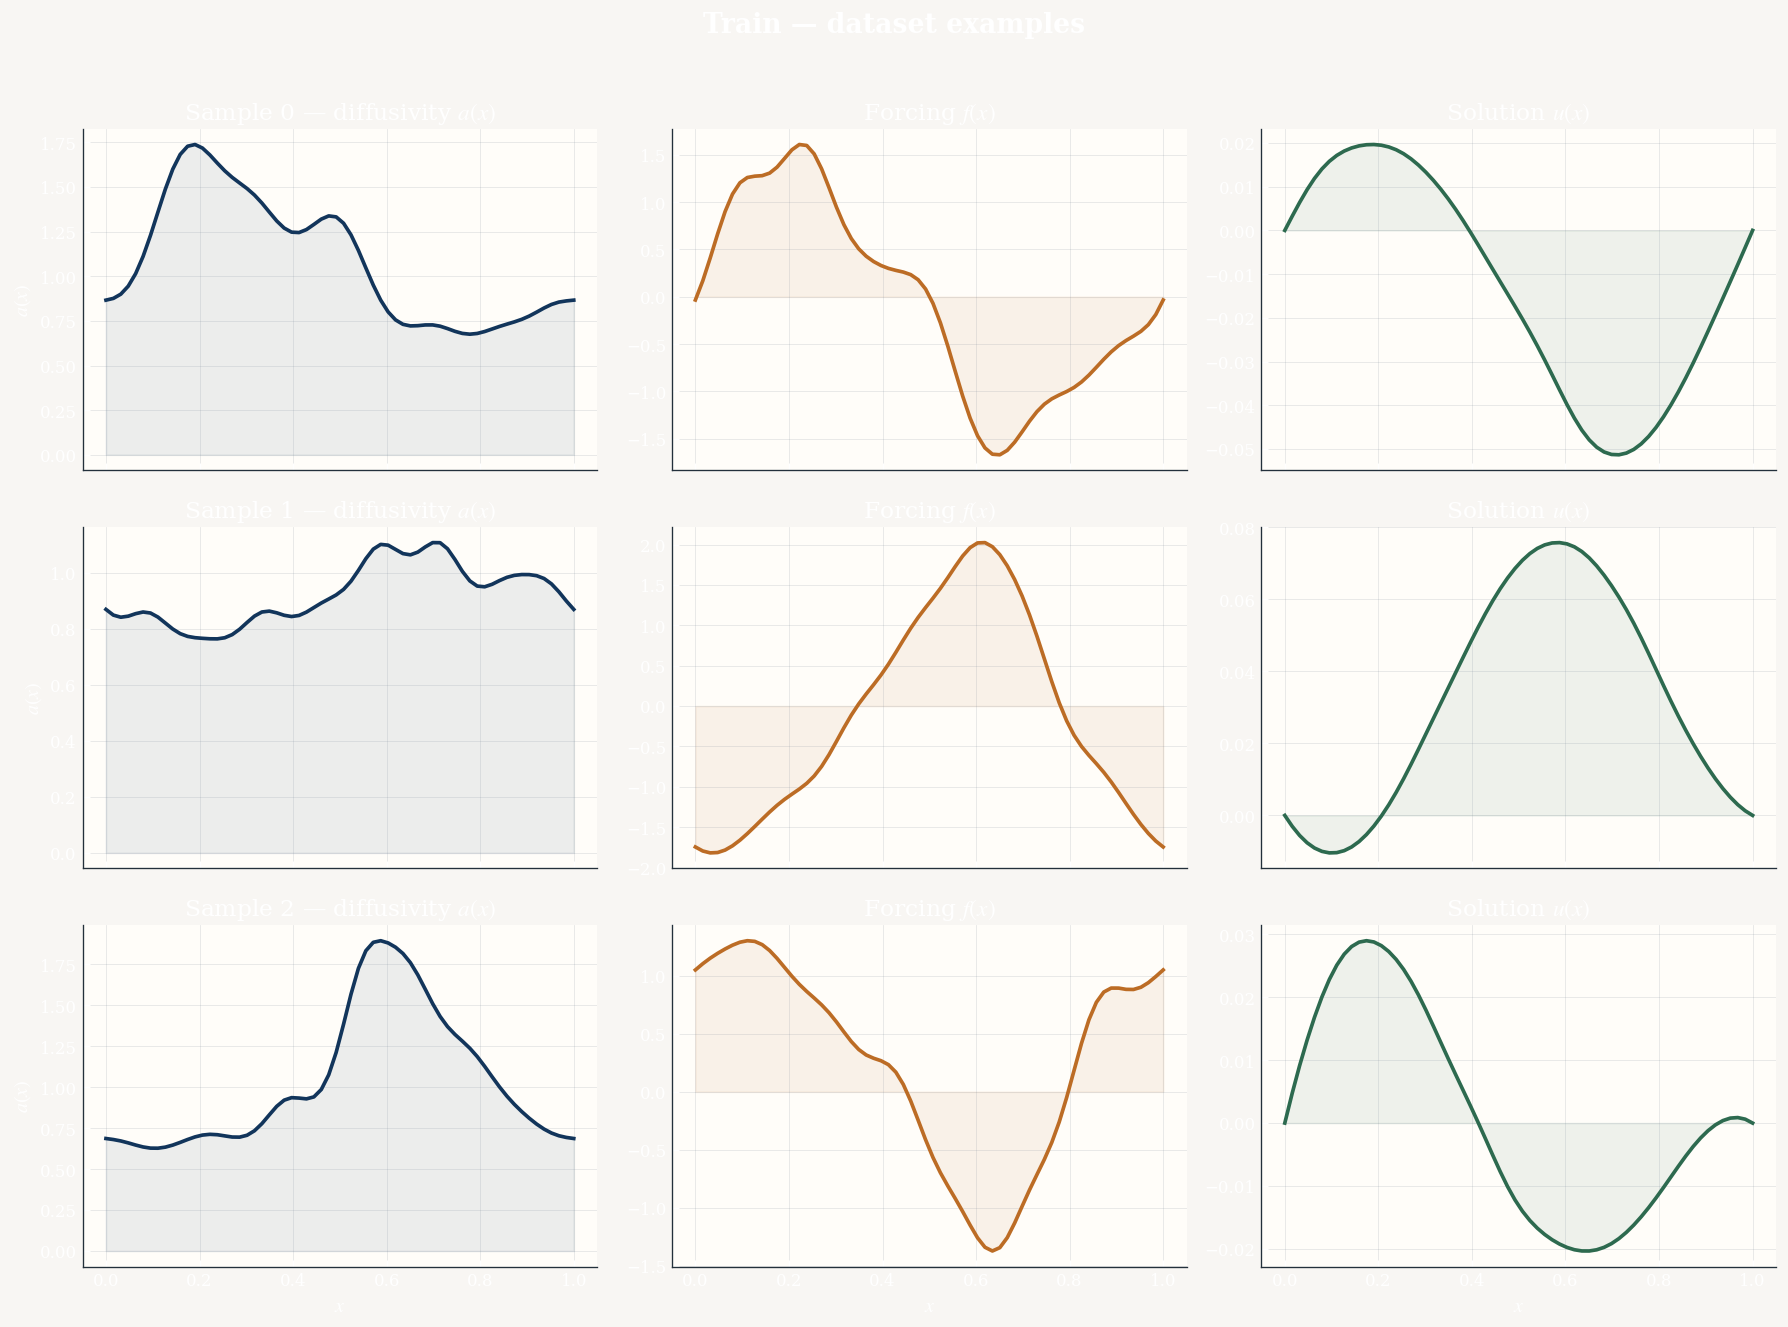

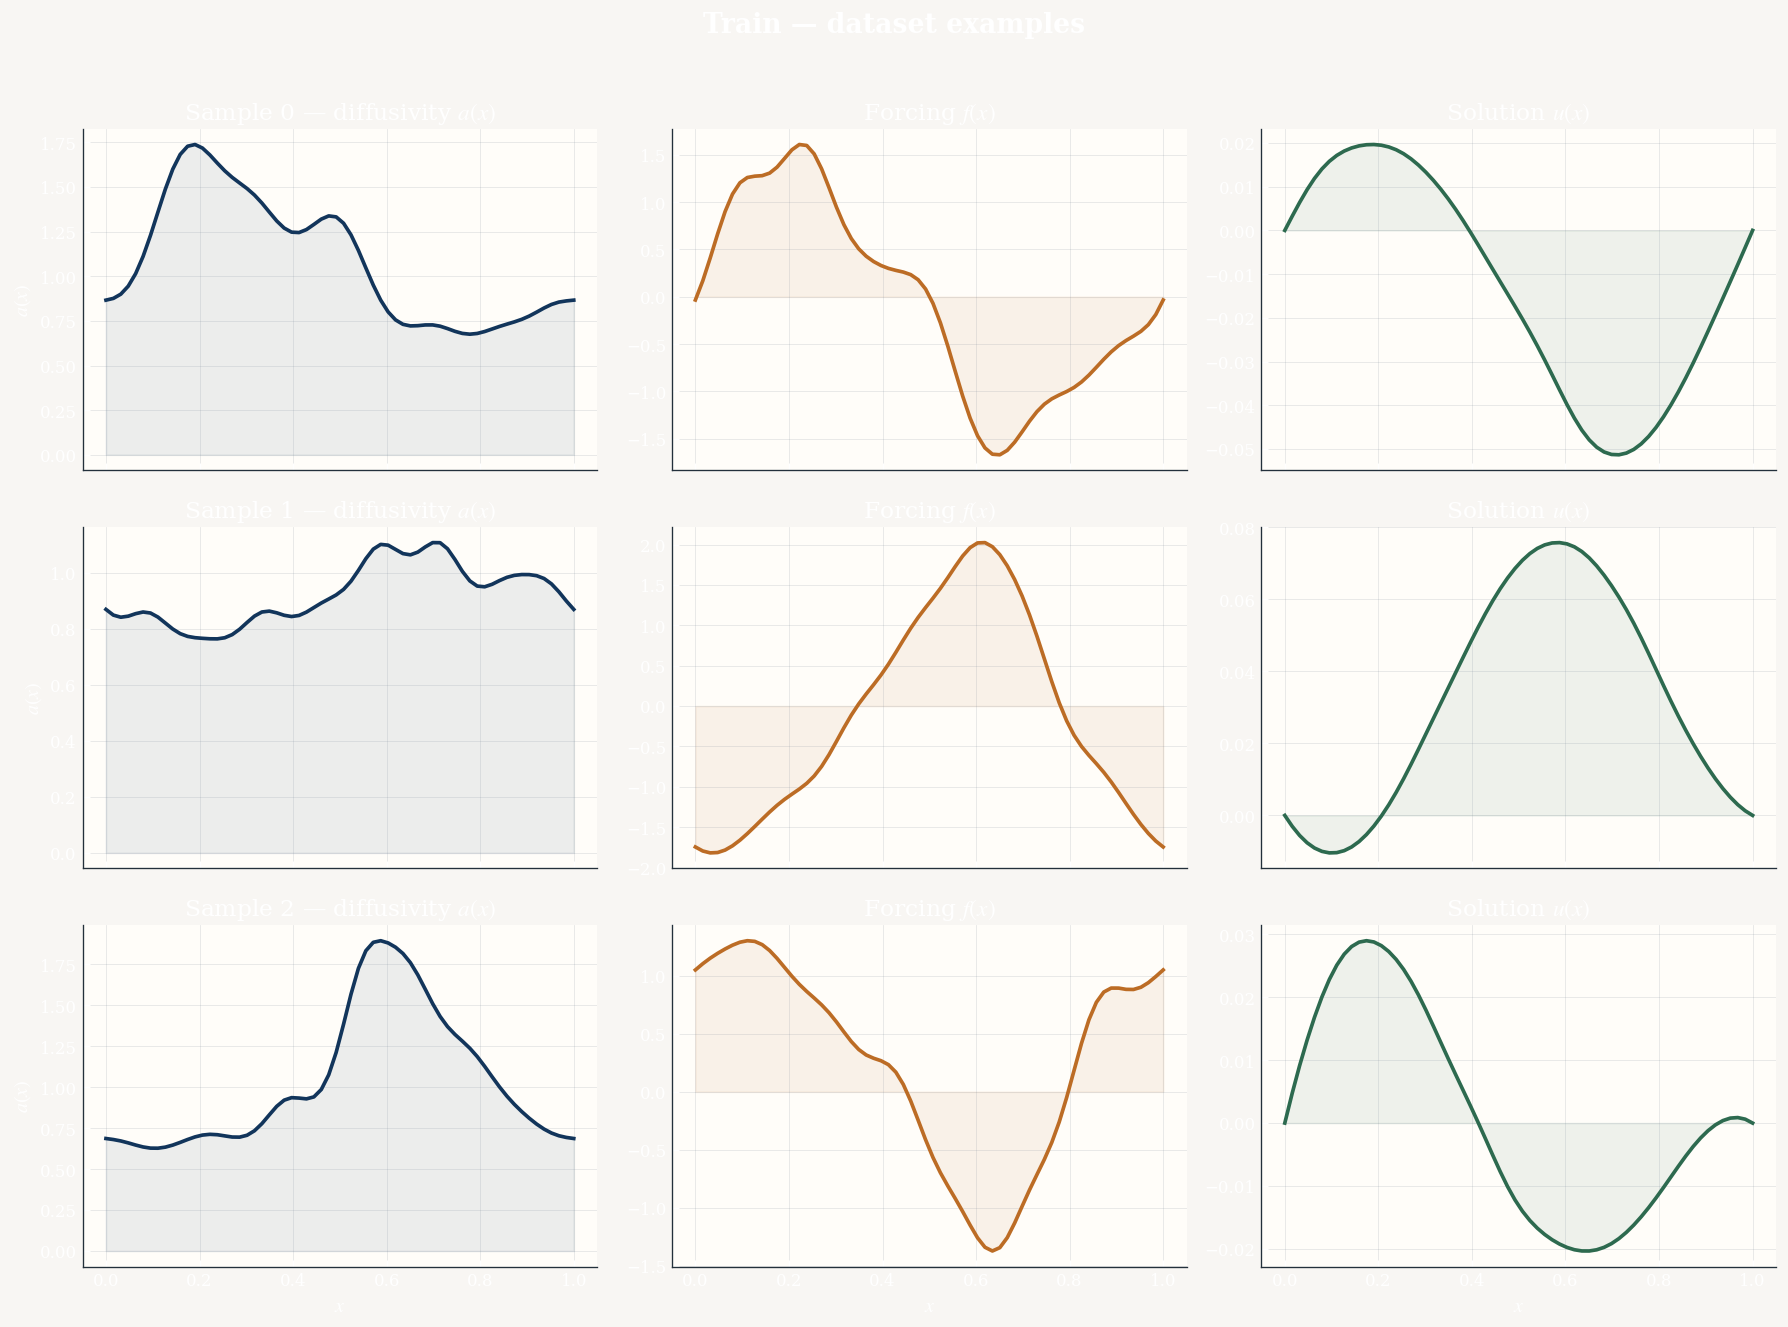

In [5]:
fig_examples = plot_dataset_examples(splits.train)
fig_examples

## 5 — FNO-1d Architecture

- A pointwise linear **lift** from `[a(x), f(x), x]` into a high-dimensional channel space
- Repeated Fourier residual blocks: spectral convolution + $1 \times 1$ local path + nonlinearity
- A pointwise **projection** back to the scalar solution channel

Because the spectral weights act on Fourier modes (not a fixed vector length), the same trained model can be evaluated on a different number of grid points.


In [6]:
model = FourierNeuralOperator1d(config.model)
print(model.architecture_string())
print(f"Trainable parameters: {model.count_parameters():,}")
model

FourierNeuralOperator1d(width=48, modes=16, layers=4, padding=8, act=gelu)
Trainable parameters: 159,457


FourierNeuralOperator1d(
  (lift): Linear(in_features=3, out_features=48, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x FourierResidualBlock1d(
      (spectral): SpectralConv1d()
      (local): Conv1d(48, 48, kernel_size=(1,), stride=(1,))
    )
  )
  (projection_in): Linear(in_features=48, out_features=48, bias=True)
  (projection_out): Linear(in_features=48, out_features=1, bias=True)
)

## 6 — Train the 1-D Neural Operator

The tutorial preset trains on a coarse grid and later evaluates on both:

- the same resolution used for training
- a finer grid the model never saw during training


In [7]:
experiment = run_neural_operator_experiment(config)

Device: cpu
Datasets: train=256×64 validation=64×64 test=64×64 refined_test=64×128
Model: FourierNeuralOperator1d(width=48, modes=16, layers=4, padding=8, act=gelu) (159,457 parameters)
  [FNO    1/80] train_loss=0.824703 val_rel_l2=0.864567 val_mse=0.001205
  [FNO   10/80] train_loss=0.014987 val_rel_l2=0.130750 val_mse=0.000028
  [FNO   20/80] train_loss=0.002860 val_rel_l2=0.088588 val_mse=0.000013
  [FNO   30/80] train_loss=0.003257 val_rel_l2=0.101628 val_mse=0.000017
  [FNO   40/80] train_loss=0.000754 val_rel_l2=0.067406 val_mse=0.000007
  [FNO   50/80] train_loss=0.001085 val_rel_l2=0.084309 val_mse=0.000011
  [FNO   60/80] train_loss=0.000324 val_rel_l2=0.066300 val_mse=0.000007
  [FNO   70/80] train_loss=0.000205 val_rel_l2=0.062889 val_mse=0.000006
  [FNO   80/80] train_loss=0.000196 val_rel_l2=0.062854 val_mse=0.000006


In [8]:
evaluation_frame = pd.DataFrame([
    {"split": ev.split, "resolution": ev.resolution, **ev.metrics.model_dump()}
    for ev in experiment.summary.evaluations.values()
])
display(evaluation_frame)

,split,resolution,relative_l2,mse,mae,max_absolute_error
0,test,64,0.038730,0.000002,0.001020,0.008155
1,refined_test,128,0.100135,0.000014,0.002884,0.018381


,epoch,train_loss,validation_loss,validation_relative_l2,learning_rate
75,76,0.000282,0.000006,0.061977,0.001029
76,77,0.000227,0.000007,0.063773,0.001029
77,78,0.000211,0.000006,0.062485,0.001029
78,79,0.000168,0.000006,0.061599,0.001029
79,80,0.000196,0.000006,0.062854,0.001029


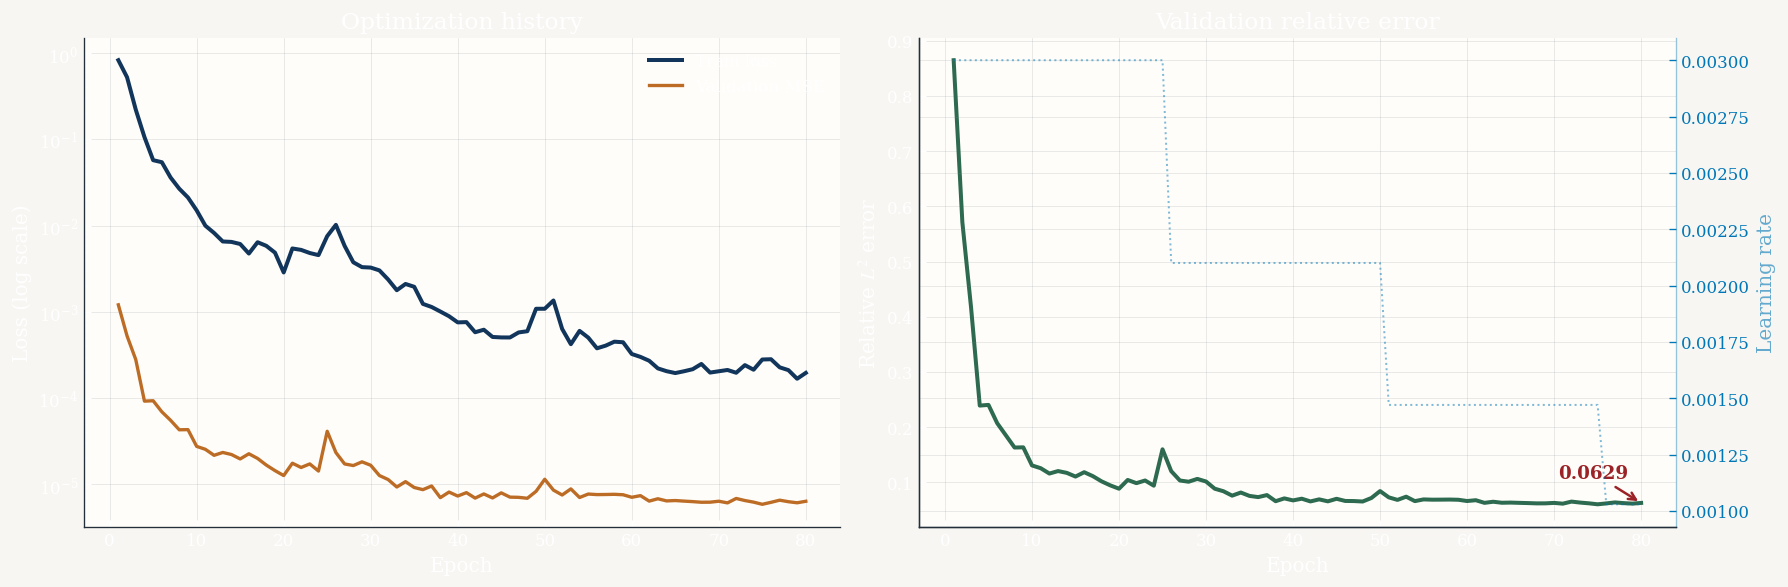

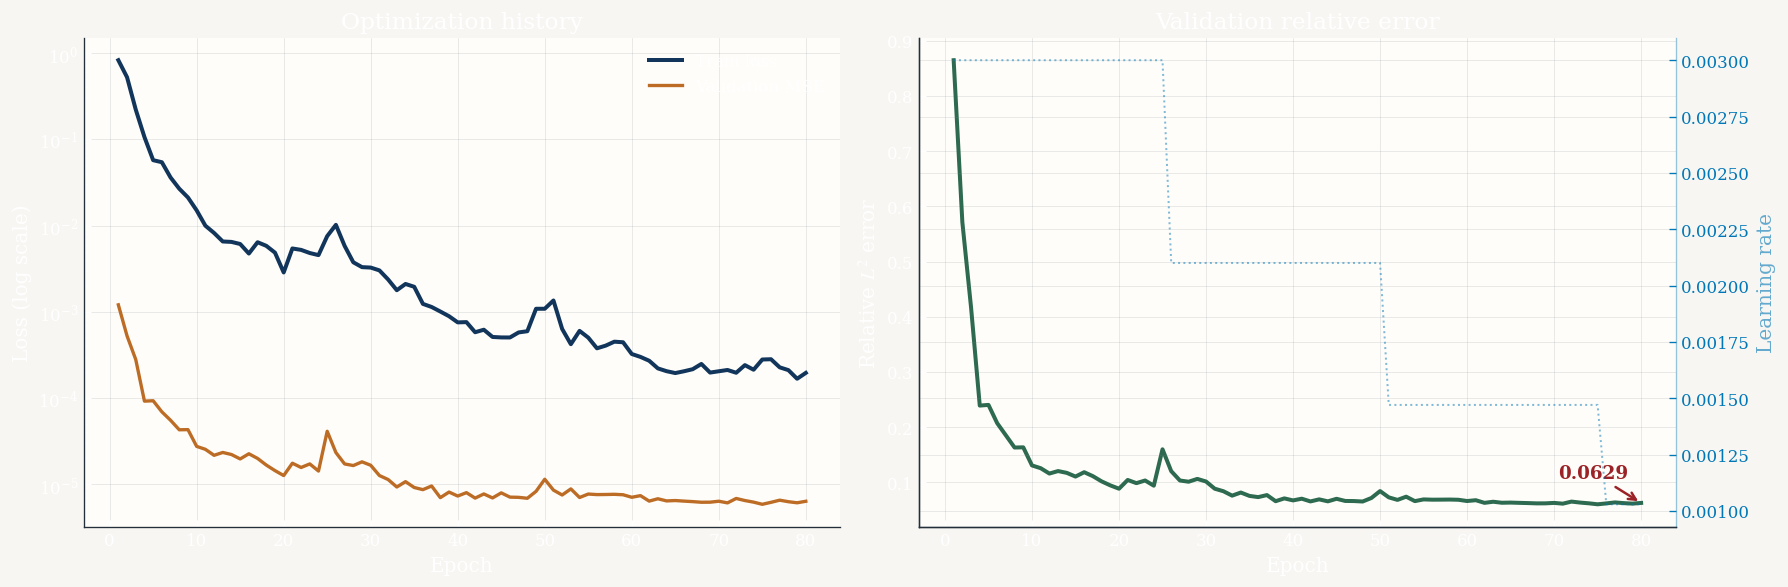

In [9]:
history_frame = experiment.history.to_frame()
display(history_frame.tail())
fig_history = plot_training_history(experiment.history)
fig_history

## 7 — Native-Resolution Prediction

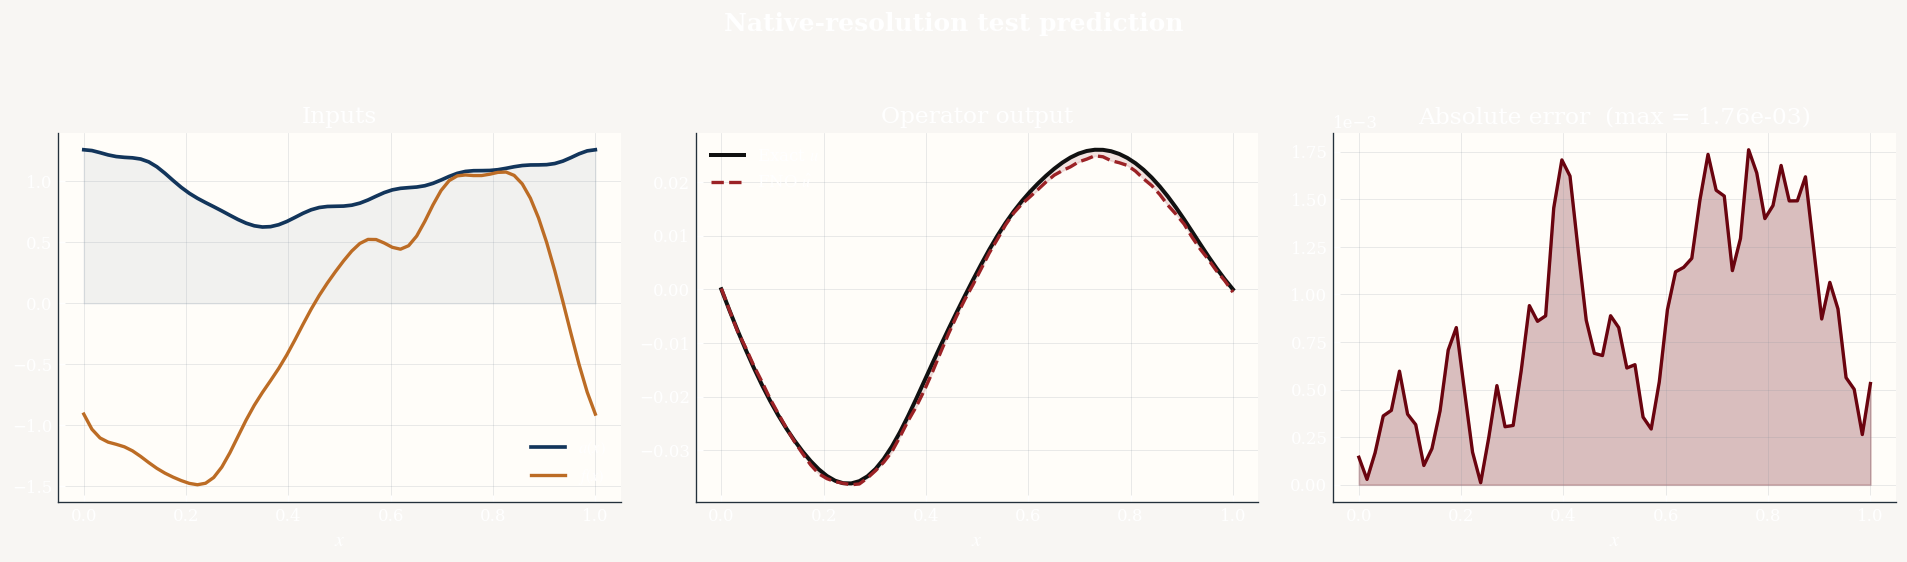

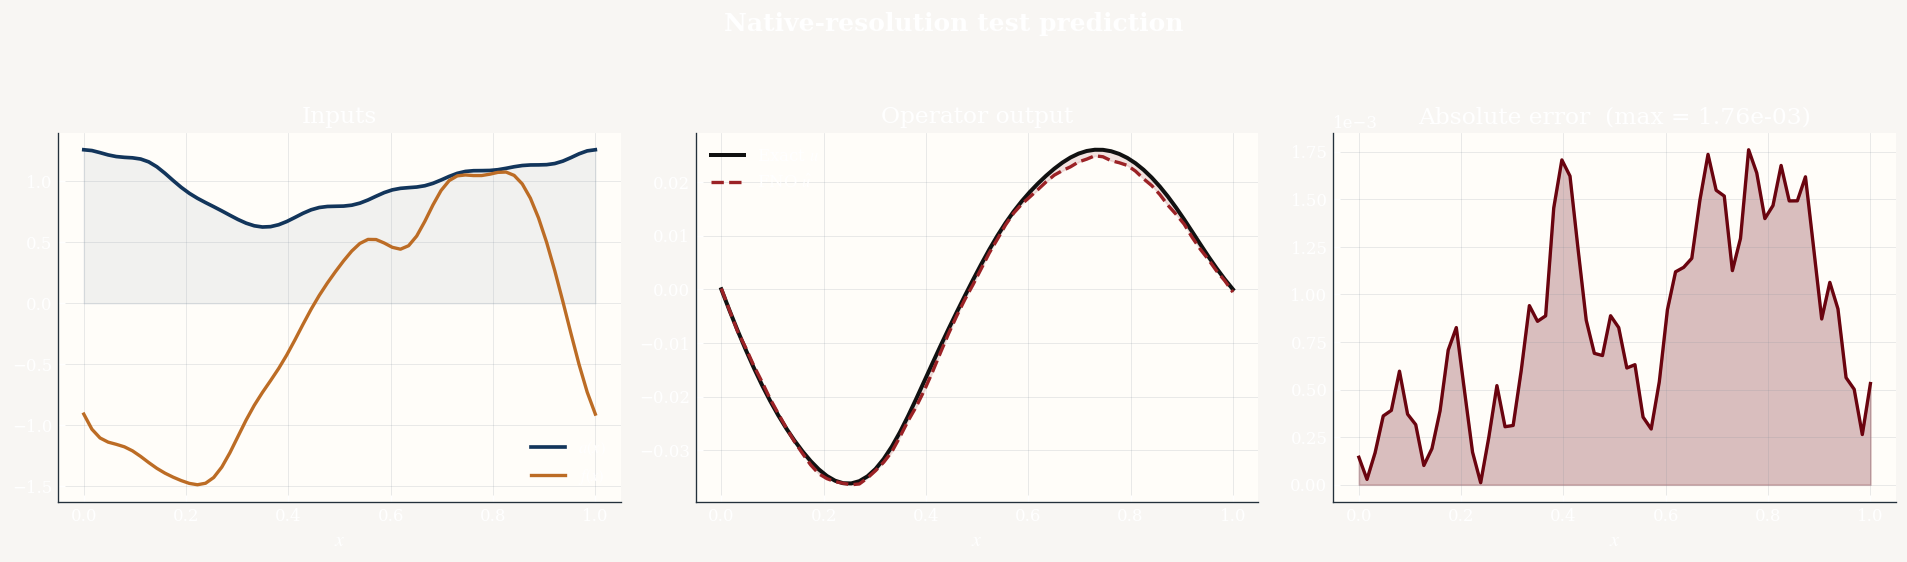

In [10]:
native_index = 0
native_sample = experiment.datasets.test.sample(native_index)
fig_native = plot_prediction_comparison(
    native_sample,
    experiment.native_prediction[native_index],
    title="Native-resolution test prediction",
)
fig_native

## 8 — Zero-Shot Resolution Transfer

We evaluate the same latent test functions on a finer grid **without retraining** the model.


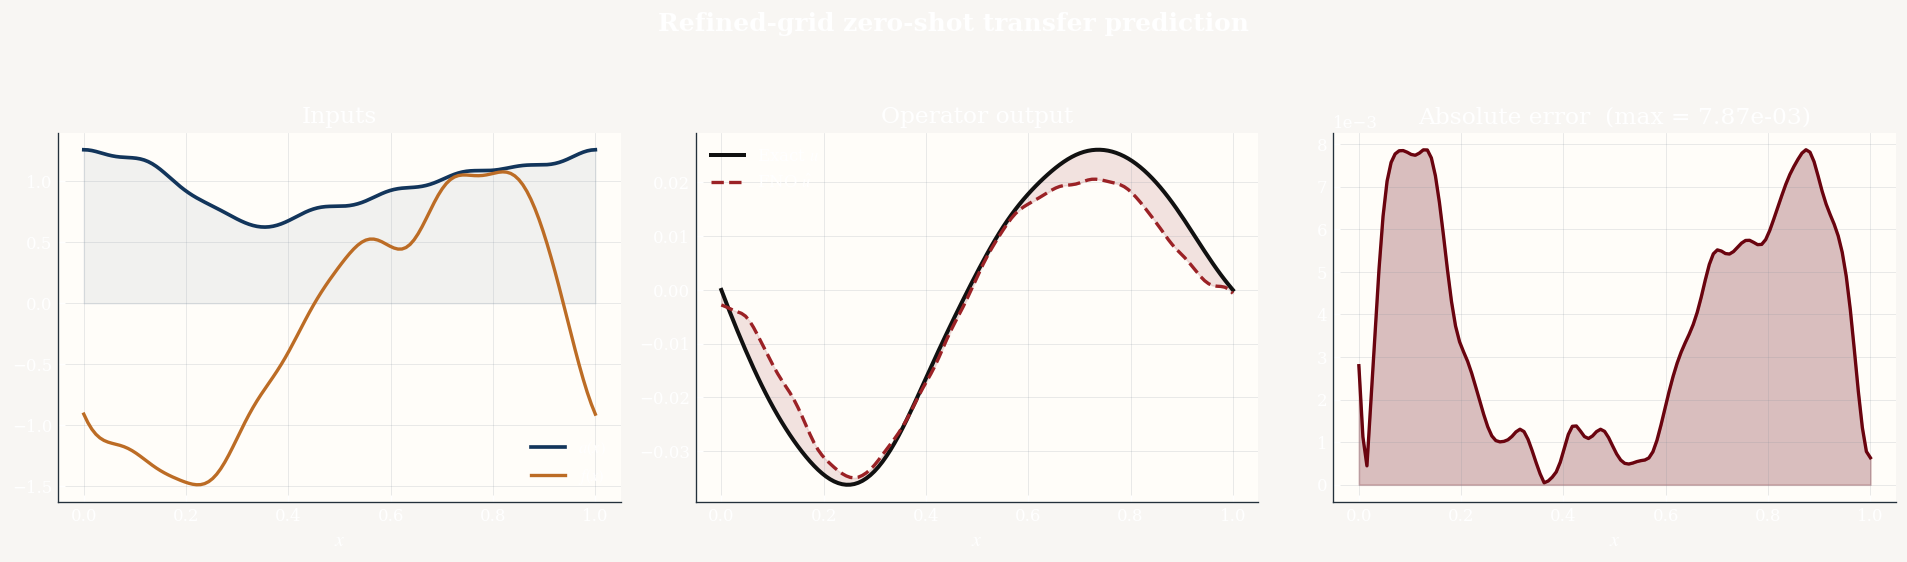

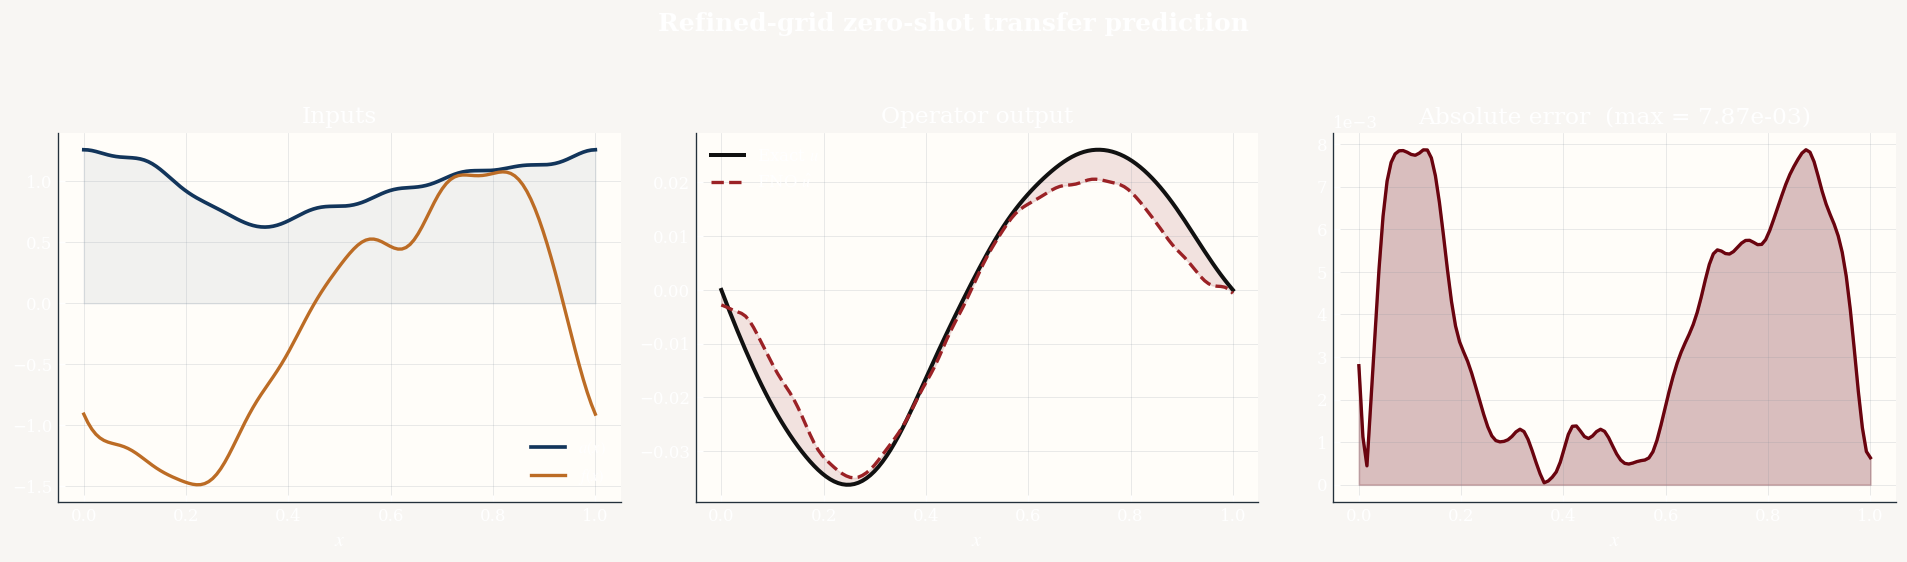

In [11]:
refined_sample = experiment.datasets.refined_test.sample(native_index)
fig_refined = plot_prediction_comparison(
    refined_sample,
    experiment.refined_prediction[native_index],
    title="Refined-grid zero-shot transfer prediction",
)
fig_refined

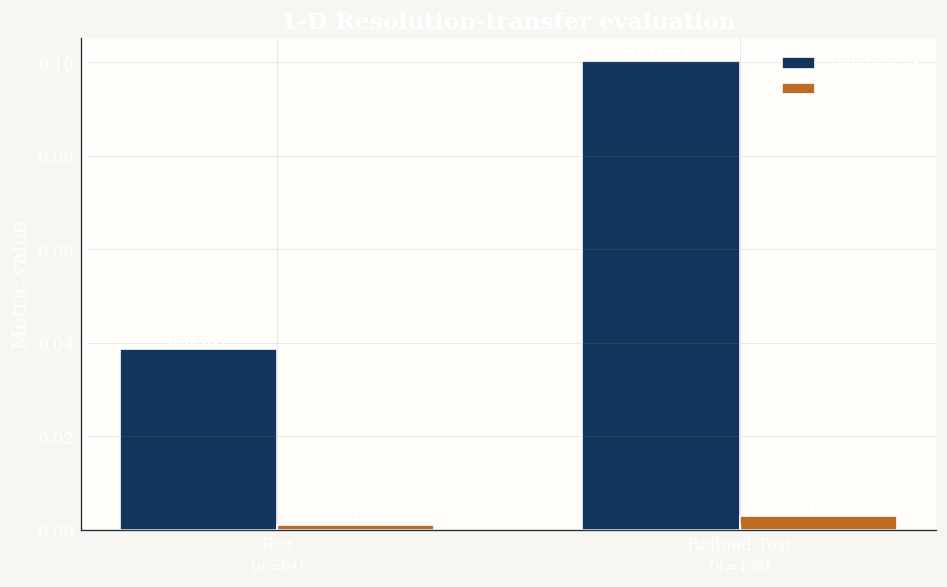

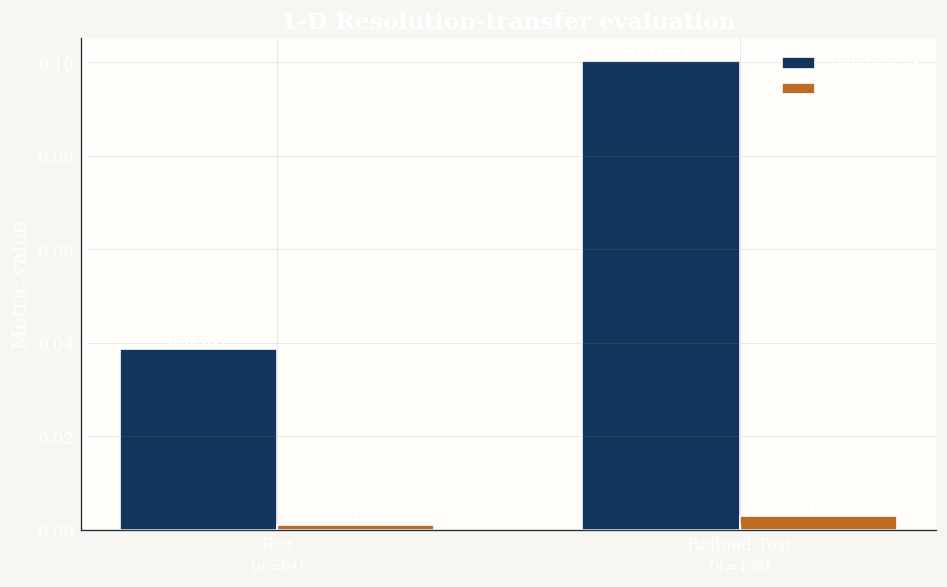

In [12]:
fig_metrics = plot_resolution_metrics(experiment.summary)
fig_metrics

In [13]:
def per_sample_relative_l2(prediction: np.ndarray, target: np.ndarray) -> np.ndarray:
    numerator = np.linalg.norm(prediction - target, axis=1)
    denominator = np.linalg.norm(target, axis=1) + 1e-12
    return numerator / denominator

native_relative = per_sample_relative_l2(experiment.native_prediction, experiment.datasets.test.solution)
refined_relative = per_sample_relative_l2(experiment.refined_prediction, experiment.datasets.refined_test.solution)
display(pd.DataFrame({"native_relative_l2": native_relative, "refined_relative_l2": refined_relative}).describe())

,native_relative_l2,refined_relative_l2
count,64.000000,64.000000
mean,0.044480,0.132490
std,0.031803,0.069106
min,0.009388,0.060637
25%,0.027506,0.080245
50%,0.036743,0.117678
75%,0.060470,0.149937
max,0.228223,0.353337


## 9 — Spectral Analysis

FNOs work well because many PDE solution operators are dominated by low-to-mid frequency structure. The spectral plot below shows how well the learned operator reproduces the target energy across Fourier modes.


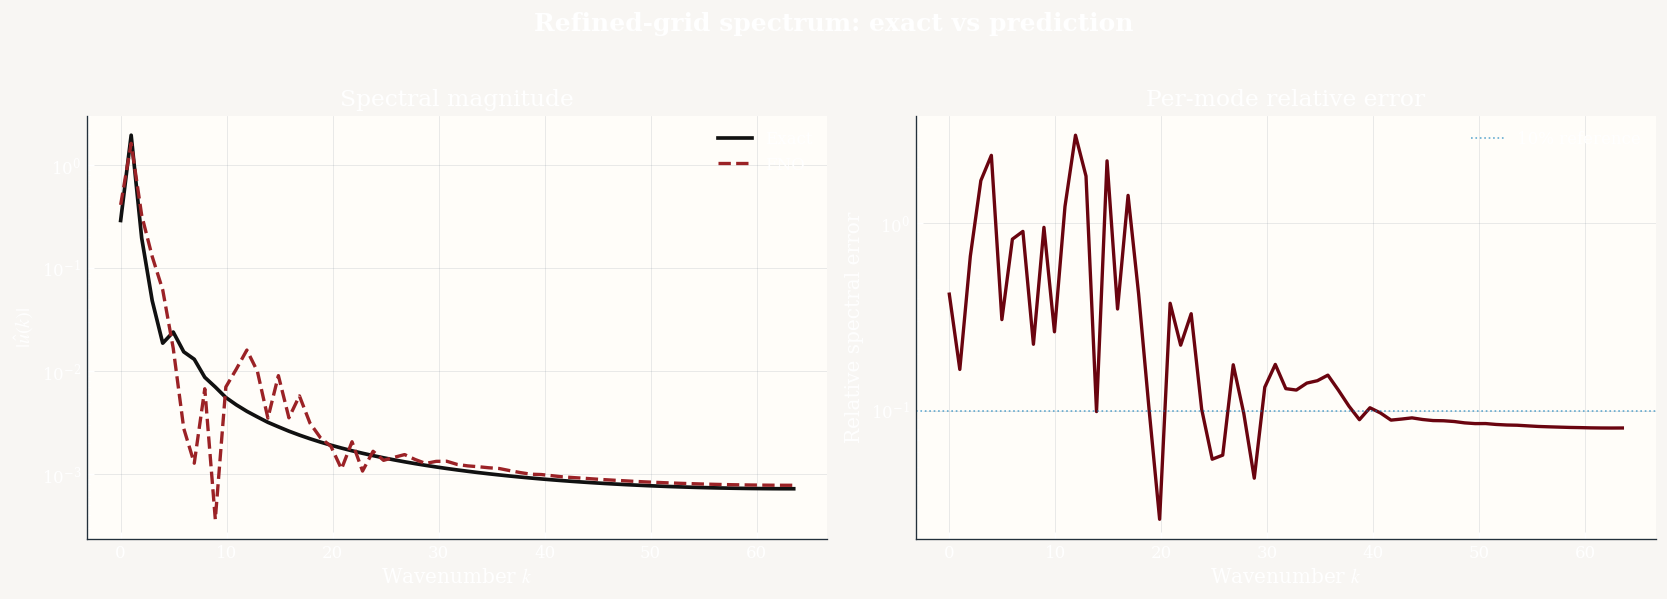

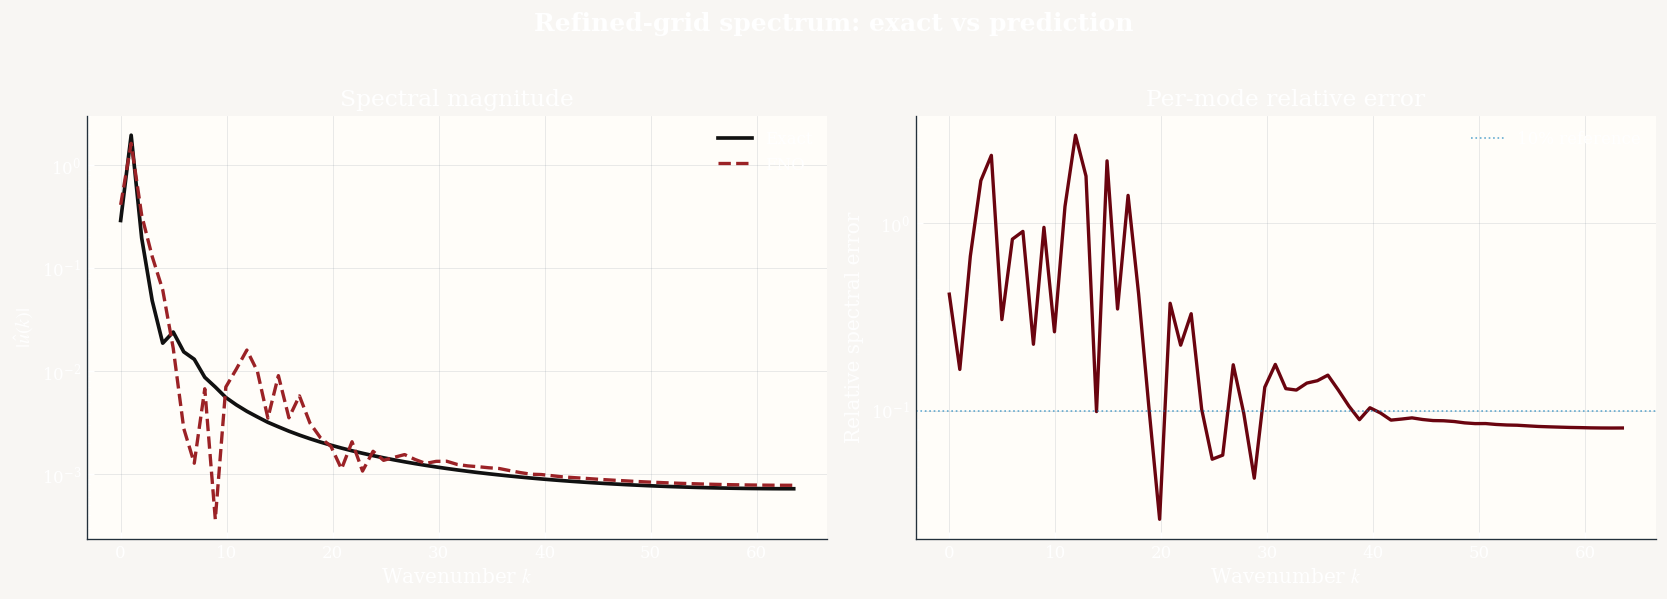

In [14]:
fig_spectrum = plot_frequency_spectrum(
    refined_sample.grid,
    refined_sample.solution,
    experiment.refined_prediction[native_index],
    title="Refined-grid spectrum: exact vs prediction",
)
fig_spectrum

In [15]:
exact_residual = compute_discrete_diffusion_residual(
    refined_sample.grid, refined_sample.diffusion, refined_sample.solution, refined_sample.forcing,
)
predicted_residual = compute_discrete_diffusion_residual(
    refined_sample.grid, refined_sample.diffusion, experiment.refined_prediction[native_index], refined_sample.forcing,
)
display(pd.DataFrame([
    {"quantity": "exact solution", "mean |residual|": np.mean(np.abs(exact_residual)), "max |residual|": np.max(np.abs(exact_residual))},
    {"quantity": "FNO prediction", "mean |residual|": np.mean(np.abs(predicted_residual)), "max |residual|": np.max(np.abs(predicted_residual))},
]))

,quantity,mean |residual|,max |residual|
0,exact solution,0.001240,0.003300
1,FNO prediction,1.344574,8.340121


---

# Part II — 2-D Darcy Flow

## 10 — The Darcy Equation and Gaussian Random Fields

We now move to a canonical 2-D benchmark: the **Darcy flow equation** on the unit square,

$$
-\nabla \cdot \big( a(x,y)\, \nabla u(x,y) \big) = f(x,y), \qquad (x,y) \in (0,1)^2, \qquad u\big|_{\partial\Omega} = 0,
$$

where:

- $a(x,y) > 0$ is a spatially varying **diffusivity** (or permeability in porous-media flow)
- $f(x,y)$ is a forcing function (we use $f \equiv 1$ throughout)
- the boundary condition is homogeneous Dirichlet

This problem is the standard benchmark used in the original FNO paper (Li et al., 2021).

### Gaussian Random Field prior

The diffusivity is drawn from a **Gaussian Random Field (GRF)** with covariance operator

$$
\mathcal{C} = \tau^{2\alpha} (-\Delta + \tau^2 I)^{-\alpha},
$$

and then thresholded to produce a **piecewise-constant** field $a(x,y) \in \{a_{\text{lo}}, a_{\text{hi}}\}$.  This creates sharp interfaces that make the problem genuinely challenging for the neural operator.

### Why this is a good benchmark

1. **Nonlocal**: a change in $a$ at one location affects $u$ everywhere via the elliptic Green's function
2. **2-D**: tests that the architecture scales beyond 1-D
3. **Resolution transfer**: the GRF is generated on a fine grid and sub-sampled for training, enabling genuine zero-shot super-resolution testing
4. **Numerically stable**: the five-point FD solver with Dirichlet BCs is well-conditioned for positive $a$


## 11 — 2-D Configuration and Data Generation


In [ ]:
darcy_config = build_darcy_tutorial_config(
    output_dir=PROJECT_ROOT / "artifacts" / "notebook_darcy"
)
display(darcy_config.model_dump())

In [ ]:
darcy_splits = build_darcy_splits(darcy_config)
darcy_dataset_frame = pd.DataFrame([
    {"split": "train", "samples": darcy_splits.train.n_samples, "resolution": f"{darcy_splits.train.resolution}×{darcy_splits.train.resolution}"},
    {"split": "validation", "samples": darcy_splits.validation.n_samples, "resolution": f"{darcy_splits.validation.resolution}×{darcy_splits.validation.resolution}"},
    {"split": "test", "samples": darcy_splits.test.n_samples, "resolution": f"{darcy_splits.test.resolution}×{darcy_splits.test.resolution}"},
    {"split": "refined_test", "samples": darcy_splits.refined_test.n_samples, "resolution": f"{darcy_splits.refined_test.resolution}×{darcy_splits.refined_test.resolution}"},
])
display(darcy_dataset_frame)

In [ ]:
fig_darcy_examples = plot_darcy_dataset_examples(darcy_splits.train, sample_indices=(0, 1, 2))
fig_darcy_examples

## 12 — FNO-2d Architecture

The 2-D model follows the same principles as the 1-D version:

- **Lift**: pointwise linear from `[a(x,y), f(x,y), x, y]` to a high-dimensional channel space
- **Fourier blocks**: 2-D spectral convolution (via `rfft2`/`irfft2`) + $1 \times 1$ `Conv2d` local path + nonlinearity
- **Project**: pointwise linear back to scalar $u(x,y)$

The spectral weights are tensors of shape `(width, width, modes_x, modes_y)` and do not depend on the spatial resolution.


In [ ]:
darcy_model = FourierNeuralOperator2d(darcy_config.model)
print(darcy_model.architecture_string())
print(f"Trainable parameters: {darcy_model.count_parameters():,}")
darcy_model

## 13 — Train the 2-D FNO on Darcy Flow

Training on the coarse ($29 \times 29$) grid, with evaluation on both native and refined ($57 \times 57$) resolutions.


In [ ]:
darcy_experiment = run_darcy_experiment(darcy_config)

In [ ]:
darcy_eval_frame = pd.DataFrame([
    {"split": ev.split, "resolution": f"{ev.resolution}×{ev.resolution}", **ev.metrics.model_dump()}
    for ev in darcy_experiment.summary.evaluations.values()
])
display(darcy_eval_frame)

In [ ]:
darcy_history = darcy_experiment.history.to_frame()
display(darcy_history.tail())
fig_darcy_history = plot_training_history(darcy_experiment.history)
fig_darcy_history

## 14 — 2-D Prediction Heatmaps

The key visualization: side-by-side comparison of the input diffusivity, exact solution, FNO prediction, and pointwise error (on a log scale).


In [ ]:
darcy_idx = 0
darcy_native_sample = darcy_experiment.datasets.test.sample(darcy_idx)
fig_darcy_native = plot_darcy_prediction_comparison(
    darcy_native_sample,
    darcy_experiment.native_prediction[darcy_idx],
    title="Darcy flow — native-resolution prediction",
)
fig_darcy_native

In [ ]:
darcy_refined_sample = darcy_experiment.datasets.refined_test.sample(darcy_idx)
fig_darcy_refined = plot_darcy_prediction_comparison(
    darcy_refined_sample,
    darcy_experiment.refined_prediction[darcy_idx],
    title="Darcy flow — zero-shot refined prediction",
)
fig_darcy_refined

## 15 — Cross-Section Comparison

1-D slices through the 2-D solution at selected $y$-values, showing exact vs predicted with error bands.


In [ ]:
fig_cross = plot_darcy_cross_sections(
    darcy_refined_sample,
    darcy_experiment.refined_prediction[darcy_idx],
    y_fractions=(0.25, 0.5, 0.75),
)
fig_cross

## 16 — Error Distribution and Resolution Transfer


In [ ]:
fig_darcy_err = plot_darcy_error_distribution(
    darcy_experiment.native_prediction,
    darcy_experiment.datasets.test.solution,
    title="Native-resolution per-sample error distribution",
)
fig_darcy_err

In [ ]:
fig_darcy_metrics = plot_darcy_resolution_metrics(darcy_experiment.summary)
fig_darcy_metrics

## 17 — Gallery: Multiple Test Predictions

Visualize predictions on several test samples to assess consistency.


In [ ]:
for idx in range(min(3, darcy_experiment.datasets.test.n_samples)):
    s = darcy_experiment.datasets.refined_test.sample(idx)
    fig = plot_darcy_prediction_comparison(
        s, darcy_experiment.refined_prediction[idx],
        title=f"Refined test sample {idx}",
    )
    display(fig)

## 18 — Interpretation and Comparison

### 1-D vs 2-D comparison

| Aspect | 1-D diffusion | 2-D Darcy flow |
|--------|--------------|----------------|
| Data source | Exact integral formula | FD solver on fine grid |
| Input channels | $[a(x), f(x), x]$ | $[a(x,y), f(x,y), x, y]$ |
| Spectral conv | 1-D FFT | 2-D FFT |
| Resolution transfer | 64 → 128 | 29² → 57² |
| Key challenge | Smooth fields, nonlocal operator | Sharp interfaces, higher dimension |

### What this notebook demonstrates

- **Operator learning**: the model maps function-valued inputs to function-valued outputs in both 1-D and 2-D
- **Discretization invariance**: the same trained parameters work at multiple resolutions
- **GRF-based benchmarking**: the 2-D Darcy flow setup matches the original FNO paper's canonical benchmark
- **Spectral efficiency**: low Fourier modes capture the dominant structure of elliptic PDE solutions

### Limitations

- The 2-D solver uses a simple 5-point FD stencil (not spectral) — accuracy is limited by grid resolution
- The piecewise-constant diffusivity creates discontinuities that challenge the spectral representation
- For production use, larger datasets, deeper models, and longer training would improve accuracy
- This notebook does not reproduce the formal approximation-theoretic guarantees from the paper
